# Script to analyze LULC measurement series

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

This script analyses the LULC measurement series from the Global Carbon Budget 2025 dataset. It extracts the BLUE, OSCAR, and LUCE series as provided, and for each LULC model column from CLASSIC through VISIT-UT, it creates three derived series by adding each peat column (FAO_peat, LPX_Bern_peat, ORCHIDEE_peat). The script saves all extracted and derived series to CSV and generates plots for all combinations, including BLUE, OSCAR, and LUCE.

## Load packages and set up the environment.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
using Plots

## Load the dataset

The data has been downloaded from the Global Carbon Budget 2025 dataset and slightly preprocessed to have the columns of interest in a single CSV file. We will load this data and verify that it has been loaded correctly by showing the last 5 rows of the first 5 columns.

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
df = CSV.read(data_path, DataFrame)

last(df[:, 1:5], 5)  # Show the last 5 rows to verify the data is loaded correctly

Only 5 columns are shown for brevity, but the dataset contains all the necessary columns for the analysis, as shown in the header of the CSV file and represented in the DataFrame.

In [1]:
all_cols = names(df)

37-element Vector{String}:
 "Year"
 "fossil emissions excluding carbonation"
 "land-use change emissions"
 "atmospheric growth"
 "ocean sink"
 "land sink"
 "cement carbonation sink"
 "budget imbalance"
 "GCB"
 "BLUE"
 ⋮
 "JULES"
 "LPJ-EOSIM"
 "LPJ-GUESS"
 "LPJml"
 "LPX"
 "Orchidee"
 "SDGVM"
 "VISIT"
 "VISIT-UT"

## Extracting the bookkeeping series

The bookkeeping series are BLUE, OSCAR, and LUCE. We will extract these series as they are provided in the dataset. They are the same used in the column land_use_change in the Global Carbon Budget 2025 dataset. Hence, we will keep them as they are provided without any modifications.

In [1]:
book_cols = ["BLUE", "OSCAR", "LUCE"]
bookkeeping_series = df[:, ["Year", book_cols...]]
first(bookkeeping_series, 5)  # Show the first 5 rows to verify the

## Individual models, not including peat

The LULC model columns from “CABLE-POP” through “VISIT-UT” represent the LULC models without any peat contribution. There are 22 such columns, as shown below.

In [1]:
lulc_model_columns = names(df)[16:end]
lulc_model_series = df[:, ["Year", lulc_model_columns...]]
first(lulc_model_series, 5)  # Show the first 5 rows to

To make them comparable to the bookkeeping series, we need to add the peat contribution to each of these LULC model columns. The peat contribution is represented by three columns: FAO_peat, LPX_Bern_peat, and ORCHIDEE_peat.

In [1]:
peat_cols = ["FAO_peat", "LPX_Bern_peat", "ORCHIDEE_peat"]
peat_series = df[:, ["Year", peat_cols...]]
first(peat_series, 5)  # Show the first 5 rows to verify the

We will create three derived series for each LULC model by adding each peat column to the respective LULC model column.

That is, for each LULC model column from CLASSIC through VISIT-UT, creates three derived series by adding each peat column: - + FAO_peat - + LPX_Bern_peat - + ORCHIDEE_peat

In [1]:
years = df.Year
out_df = DataFrame(year = years)

for c in book_cols
    out_df[!, Symbol(c)] = Float64.(df[!, c])
end

for base in lulc_model_columns
    base_vals = Float64.(df[!, base])
    for peat in peat_cols
        peat_vals = Float64.(df[!, peat])
        out_name = Symbol("$(base)_plus_$(peat)")
        out_df[!, out_name] = base_vals .+ peat_vals
    end
end

In [1]:
names(out_df)  # Show the column names of the output DataFrame to verify the derived series

70-element Vector{String}:
 "year"
 "BLUE"
 "OSCAR"
 "LUCE"
 "CABLE-POP_plus_FAO_peat"
 "CABLE-POP_plus_LPX_Bern_peat"
 "CABLE-POP_plus_ORCHIDEE_peat"
 "CLASSIC_plus_FAO_peat"
 "CLASSIC_plus_LPX_Bern_peat"
 "CLASSIC_plus_ORCHIDEE_peat"
 ⋮
 "SDGVM_plus_FAO_peat"
 "SDGVM_plus_LPX_Bern_peat"
 "SDGVM_plus_ORCHIDEE_peat"
 "VISIT_plus_FAO_peat"
 "VISIT_plus_LPX_Bern_peat"
 "VISIT_plus_ORCHIDEE_peat"
 "VISIT-UT_plus_FAO_peat"
 "VISIT-UT_plus_LPX_Bern_peat"
 "VISIT-UT_plus_ORCHIDEE_peat"

## Save the extracted and derived series to CSV

In [1]:
output_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")
CSV.write(output_path, out_df)

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/LULC_measurements_extracted_and_derived.csv"

## Generate plots for all combinations, including BLUE, OSCAR, and LUCE


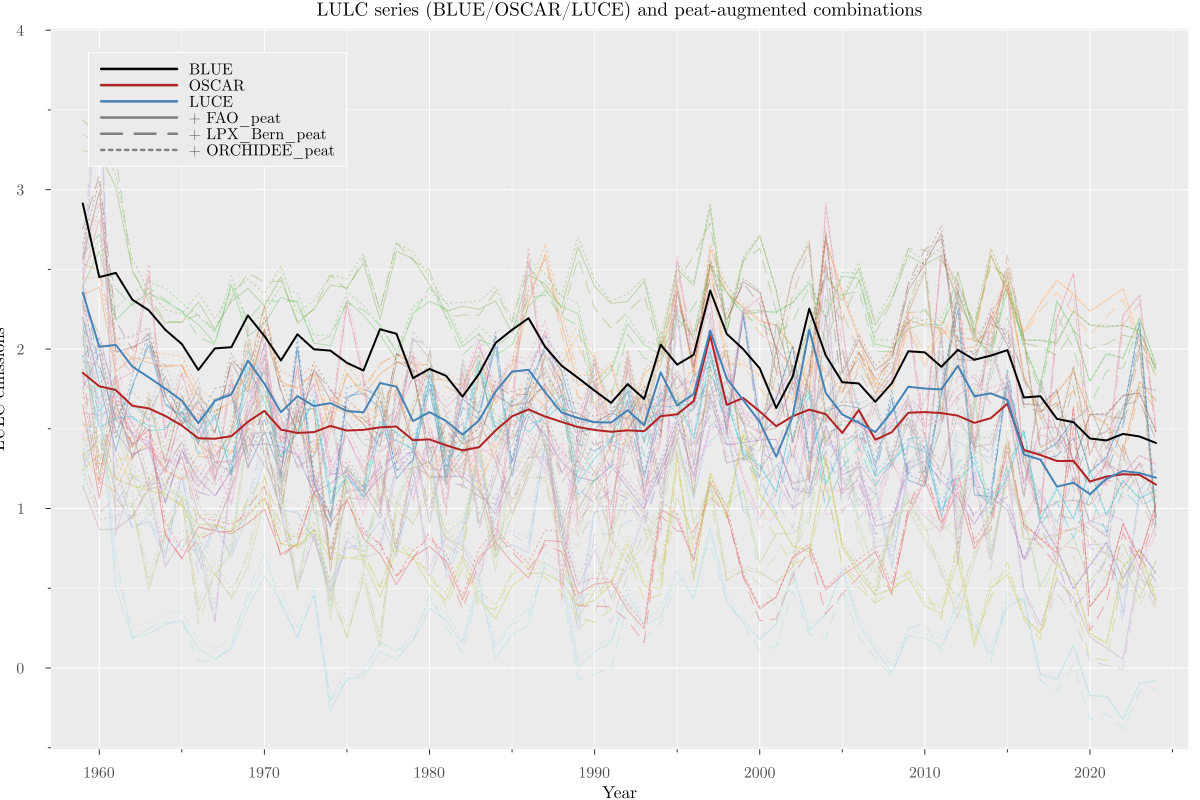

In [1]:
theme(:ggplot2)
default(fontfamily = "Computer Modern", tickfontsize = 10, legendfontsize = 10,
 titlefontsize = 12, size = (1200, 800))

peat_styles = Dict(
    "FAO_peat" => :solid,
    "LPX_Bern_peat" => :dash,
    "ORCHIDEE_peat" => :dot,
)

n_colors = max(length(lulc_model_columns), 20)
pal = [cgrad(:tab20)[i] for i in range(0, 1, length = n_colors)]

p = plot(
    xlabel = "Year",
    ylabel = "LULC emissions",
    title = "LULC series (BLUE/OSCAR/LUCE) and peat-augmented combinations",
    legend = :topleft,
)

for (i, base) in enumerate(lulc_model_columns)
    color = pal[1 + ((i - 1) % n_colors)]
    for peat in peat_cols
        sname = Symbol("$(base)_plus_$(peat)")
        plot!(
            p,
            years,
            out_df[!, sname];
            color = color,
            alpha = 0.4,
            linestyle = peat_styles[peat],
            linewidth = 1,
            label = "",
        )
    end
end

plot!(p, years, out_df.BLUE; color = :black, linewidth = 2.0, label = "BLUE")
plot!(p, years, out_df.OSCAR; color = :firebrick, linewidth = 2.0, label = "OSCAR")
plot!(p, years, out_df.LUCE; color = :steelblue, linewidth = 2.0, label = "LUCE")

# Dummy series to show peat style mapping in legend
plot!(p, [NaN], [NaN]; color = :gray, linestyle = :solid, linewidth = 2.0, label = "+ FAO_peat")
plot!(p, [NaN], [NaN]; color = :gray, linestyle = :dash, linewidth = 2.0, label = "+ LPX_Bern_peat")
plot!(p, [NaN], [NaN]; color = :gray, linestyle = :dot, linewidth = 2.0, label = "+ ORCHIDEE_peat")

In [1]:
savefig(p, joinpath(@__DIR__, "..", "figures", "LULC_series_with_peat_combinations.png"))
savefig(p, joinpath(@__DIR__, "..", "figures", "LULC_series_with_peat_combinations.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/LULC_series_with_peat_combinations.pdf"